# Modal Analysis — Analysis Methods

This notebook documents the signal-processing methods used in Pages 1–5 of the Streamlit app.

**System model throughout:**

$$x(t) \xrightarrow{h(t)} y(t)$$

where $x$ is the input (force/excitation) and $y$ is the output (response).

---
## Page 1 — Time History

### 1.1 Time-range trimming

A boolean mask selects the samples within the user-chosen window $[t_1, t_2]$:

$$\text{mask} = \{i : t_1 \leq t_i \leq t_2\}$$

All downstream statistics and spectral pages operate on the trimmed signal.

### 1.2 Butterworth digital filter

The filter is designed with `scipy.signal.butter` and applied zero-phase with `sosfiltfilt`.

#### Design

An $N$-th order Butterworth filter has a maximally-flat magnitude response:

$$|H(f)|^2 = \frac{1}{1 + \left(\dfrac{f}{f_c}\right)^{2N}}$$

The normalised cutoff frequency passed to scipy is:

$$W_n = \frac{f_c}{f_{\text{Nyquist}}} = \frac{f_c}{f_s/2} \in (0, 1)$$

For two-sided filters (bandpass / bandstop) $W_n = [W_{n,\text{low}},\; W_{n,\text{high}}]$.

| Filter type | `btype` | Passband |
|---|---|---|
| Lowpass | `'low'` | $f \leq f_c$ |
| Highpass | `'high'` | $f \geq f_c$ |
| Bandpass | `'bandpass'` | $f_{\text{low}} \leq f \leq f_{\text{high}}$ |
| Bandstop | `'bandstop'` | $f \leq f_{\text{low}}$ or $f \geq f_{\text{high}}$ |

#### Zero-phase application

`sosfiltfilt` performs two passes (forward and reverse), yielding zero group delay and doubling the effective filter order:

$$y = \text{sosfiltfilt}(\text{sos},\; x) \implies |H_{\text{eff}}(f)|^2 = |H(f)|^4$$

The output has the same length as the input; edge effects are minimised by padding.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, freqz_sos

fs = 1000.0          # example sample rate (Hz)
nyq = fs / 2.0
order = 4
fc = 100.0           # cutoff (Hz)

sos_lp = butter(order, fc / nyq, btype='low', output='sos')
sos_hp = butter(order, fc / nyq, btype='high', output='sos')
sos_bp = butter(order, [50/nyq, 200/nyq], btype='bandpass', output='sos')
sos_bs = butter(order, [50/nyq, 200/nyq], btype='bandstop', output='sos')

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
labels = ['Lowpass 100 Hz', 'Highpass 100 Hz', 'Bandpass 50–200 Hz', 'Bandstop 50–200 Hz']
for ax, sos, label in zip(axes.flat, [sos_lp, sos_hp, sos_bp, sos_bs], labels):
    w, h = freqz_sos(sos, worN=2048, fs=fs)
    ax.plot(w, 20 * np.log10(np.maximum(np.abs(h), 1e-12)))
    ax.set_title(f'Order {order} Butterworth — {label}')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_ylim(-80, 5)
    ax.grid(True)
plt.tight_layout()
plt.show()

---
## Page 2 — FFT

Page 2 offers two methods: **Single FFT** and **Welch PSD**.

### 2.1 Single FFT

#### Windowing

Window are used to make the sampled data more periodic than it really is in order to minimize leakage.  When the sample data is not periodic in the sample interval the actual energy is smeared across the spectrum and energy leaks to adjacent frequencies. This causes a distortion in frequency and amplitude measurement.

Before transforming, each signal is multiplied by a window $w[n]$ of the same length $N$:

$$\tilde{x}[n] = x[n] \cdot w[n], \quad n = 0, 1, \ldots, N-1$$

Windows available and their typical uses:

| App label | scipy name | Best for | Comment |
|---|---|---|---|
| Uniform | `boxcar` | Periodic signals, no spectral leakage concern | Used when signal periodic |
| Hanning | `hann` | General-purpose, good sidelobe rejection | Good freq resolution, minimal amplitude distortion |
| Flat Top | `flattop` | Accurate amplitude measurement | Good for amplitude measurement |
| Force | `hann` | Impulsive input (short Hann window) | Useful for impulse input channel |
| Exponential | `exponential` | Decaying free-vibration responses | Useful for damped response |

#### One-sided DFT

The one-sided (real-input) DFT via `np.fft.rfft`:

$$X[k] = \sum_{n=0}^{N-1} \tilde{x}[n]\, e^{-j 2\pi k n / N}, \quad k = 0, 1, \ldots, \lfloor N/2 \rfloor$$

Frequency bins (Hz):

$$f_k = \frac{k \cdot f_s}{N}, \quad \Delta f = \frac{f_s}{N}$$

#### Display modes

**Gain / Phase:**
$$\text{Gain}[k] = |X[k]|, \qquad \text{Phase}[k] = \angle X[k] \text{ (deg)}$$

**Real / Imaginary:**
$$\text{Real}[k] = \operatorname{Re}\{X[k]\}, \qquad \text{Imag}[k] = \operatorname{Im}\{X[k]\}$$

### 2.2 Welch PSD

Welch's method reduces variance by averaging periodograms over $K$ overlapping segments of length $L$ (`nperseg`).

$$\hat{S}_{xx}(f) = \frac{1}{K} \sum_{k=0}^{K-1} \frac{1}{f_s \, U} \left| \sum_{n=0}^{L-1} x_k[n]\, w[n]\, e^{-j2\pi f n / f_s} \right|^2$$

where $U = \frac{1}{L}\sum_{n=0}^{L-1} w[n]^2$ normalises for the window power.

Key parameters:

| Parameter | Symbol | Effect |
|---|---|---|
| Segment length | $L$ = `nperseg` $= N / K$ | Frequency resolution $\Delta f = f_s / L$ |
| Overlap | `noverlap` $= L \times p / 100$ | More overlap → more segments → lower variance |
| Window | `window` | Trades sidelobe rejection vs. amplitude accuracy |

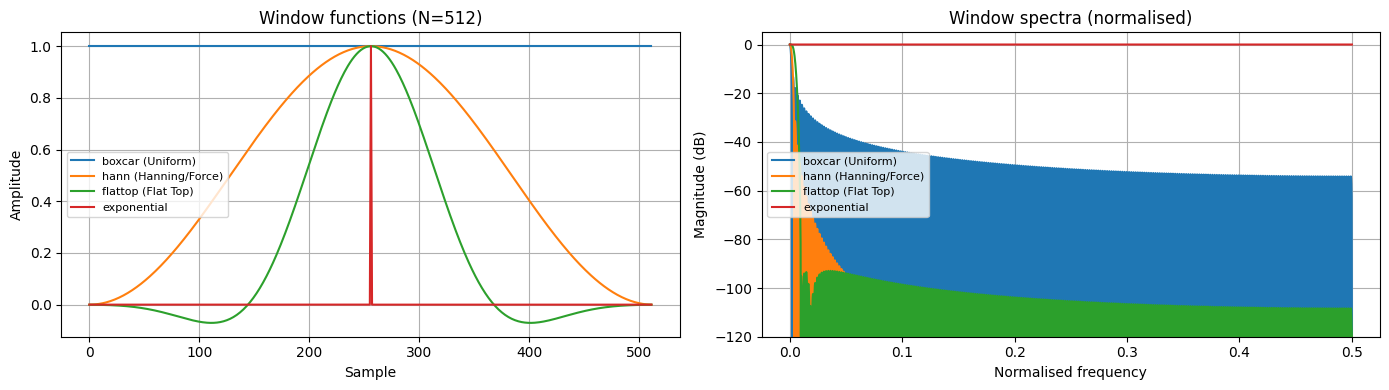

In [5]:
from scipy.signal import get_window, welch as scipy_welch

# --- Window shapes ---
N = 512
windows = {
    'boxcar (Uniform)': 'boxcar',
    'hann (Hanning/Force)': 'hann',
    'flattop (Flat Top)': 'flattop',
    'exponential': ('exponential', None, 1.0 / 8.686),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, spec in windows.items():
    w = get_window(spec, N)
    axes[0].plot(w, label=name)
    W = np.fft.rfft(w, n=4096)
    f = np.fft.rfftfreq(4096)
    axes[1].plot(f, 20 * np.log10(np.maximum(np.abs(W) / np.max(np.abs(W)), 1e-6)), label=name)

axes[0].set_title('Window functions (N=512)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].set_title('Window spectra (normalised)')
axes[1].set_xlabel('Normalised frequency')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_ylim(-120, 5)
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

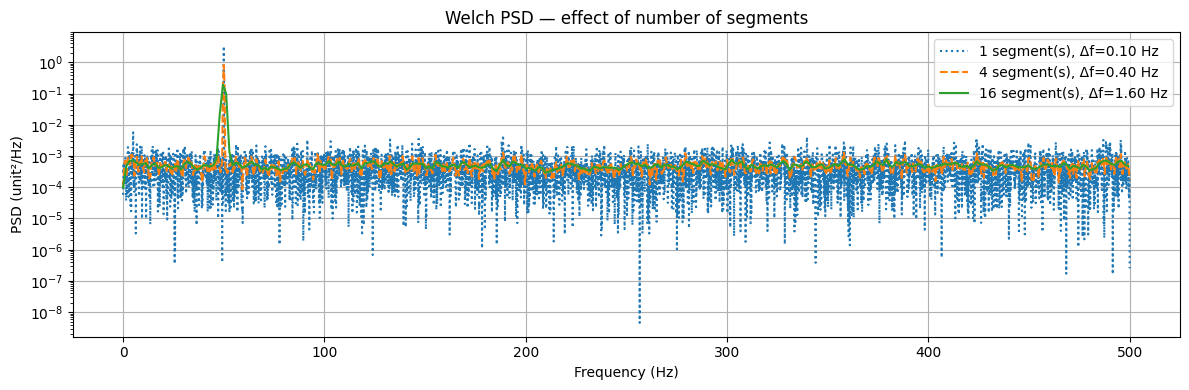

In [6]:
# --- Welch variance reduction demo ---
rng = np.random.default_rng(0)
fs = 1000.0
t = np.arange(0, 10, 1/fs)
# 50 Hz sinusoid + broadband noise
x = np.sin(2 * np.pi * 50 * t) + 0.5 * rng.standard_normal(len(t))

fig, ax = plt.subplots(figsize=(12, 4))

for n_segs, style in [(1, 'dotted'), (4, 'dashed'), (16, 'solid')]:
    nperseg = max(16, len(x) // n_segs)
    f, Pxx = scipy_welch(x, fs=fs, window='hann', nperseg=nperseg, noverlap=nperseg//2)
    ax.semilogy(f, Pxx, linestyle=style, label=f'{n_segs} segment(s), Δf={fs/nperseg:.2f} Hz')

ax.set_title('Welch PSD — effect of number of segments')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (unit²/Hz)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---
## Page 3 — Spectral Analysis

### 3.1 Spectral quantities

Given complex FFT arrays $S_x[k]$ (input) and $S_y[k]$ (output), or their Welch-averaged equivalents:

| Quantity | Formula | Units |
|---|---|---|
| Input auto-power | $G_{xx} = S_x S_x^*$ | amplitude² |
| Output auto-power | $G_{yy} = S_y S_y^*$ | amplitude² |
| Cross-power (yx) | $G_{yx} = S_y S_x^*$ | complex amplitude² |
| Cross-power (xy) | $G_{xy} = G_{yx}^* = S_x S_y^*$ | complex amplitude² |

For Welch, these are ensemble-averaged over $K$ segments before the FRF and coherence are formed.

### 3.2 PSD normalisation

The auto-power from `scipy.signal.welch` is already a two-sided PSD normalised to unit²/Hz.  
For the **Single FFT** path the raw periodogram is converted:

$$S_{xx}(f) = \frac{2\, G_{xx}[k]}{f_s \, N}$$

(factor of 2 folds the negative-frequency energy into the one-sided spectrum).

### 3.3 FRF estimators

Three estimators handle different noise scenarios:

$$H_1(f) = \frac{G_{yx}}{G_{xx}} \qquad \text{(minimises output noise bias)}$$

$$H_2(f) = \frac{G_{yy}}{G_{xy}} \qquad \text{(minimises input noise bias)}$$

$$H_v(f) = \sqrt{|H_1||H_2|}\, e^{j\angle H_1} \qquad \text{(geometric-mean magnitude, } H_1 \text{ phase)}$$

All three are identical when coherence $\gamma^2 = 1$.

### 3.4 Ordinary coherence

$$\gamma^2(f) = \frac{|G_{yx}|^2}{G_{xx}\, G_{yy}} \in [0, 1]$$

- $\gamma^2 = 1$ for a single-realisation FFT (always, by definition).
- For Welch estimates, $\gamma^2 < 1$ indicates extraneous noise, nonlinearity, or leakage.
- The app flags $\gamma^2 = 0.85$ as a practical acceptability threshold.

### 3.5 Method comparison

| Property | Single FFT | Welch |
|---|---|---|
| Frequency resolution $\Delta f$ | $f_s / N$ (maximum) | $f_s / L$, reduced |
| Variance | High | Reduced by $\sim 1/K$ |
| Coherence | Always 1 | Meaningful |
| Input required | Saved `fft_results` | Raw / processed signals |

In [ ]:
import sys, os
# Add project root so core.spectral is importable
sys.path.insert(0, os.path.join(os.getcwd()))

from core.spectral import compute_fft, compute_spectral_quantities, compute_welch_quantities

# --- Synthetic SDOF system ---
rng = np.random.default_rng(42)
fs = 1000.0
t = np.arange(0, 20, 1/fs)
N = len(t)

# White noise input
x = rng.standard_normal(N)

# SDOF impulse response: fn=50 Hz, zeta=0.05
fn, zeta = 50.0, 0.05
wn = 2 * np.pi * fn
wd = wn * np.sqrt(1 - zeta**2)
dt = 1.0 / fs
h = np.exp(-zeta * wn * np.arange(N) * dt) * np.sin(wd * np.arange(N) * dt) / wd

# Response = convolution + measurement noise
y_clean = np.convolve(h, x)[:N]
y = y_clean + 0.05 * rng.standard_normal(N)

# --- Single FFT ---
freqs_s, Sx = compute_fft(x, fs, window='hanning')
_, Sy = compute_fft(y, fs, window='hanning')
sq_s = compute_spectral_quantities(Sx, Sy)

# --- Welch ---
sq_w = compute_welch_quantities(x, y, fs, nperseg=1024, noverlap=512, window='hann')
freqs_w = sq_w['freqs']

# --- Plot ---
eps = np.finfo(float).tiny

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)

for col, (method_label, freqs, sq) in enumerate([
    ('Single FFT', freqs_s, sq_s),
    ('Welch (1024 samples/seg, 50% overlap)', freqs_w, sq_w),
]):
    mask = freqs <= 200
    f = freqs[mask]

    # Auto-power (dB)
    axes[0, col].plot(f, 10 * np.log10(np.maximum(sq['Gxx'][mask], eps)), label='Gxx (input)')
    axes[0, col].plot(f, 10 * np.log10(np.maximum(sq['Gyy'][mask], eps)), label='Gyy (output)', alpha=0.8)
    axes[0, col].set_title(f'Auto-power — {method_label}')
    axes[0, col].set_ylabel('PSD (dB)')
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(True)

    # FRF magnitude (dB)
    H1 = sq['H1'][mask]
    H2 = sq['H2'][mask]
    Hv = sq['Hv'][mask]
    axes[1, col].plot(f, 20 * np.log10(np.maximum(np.abs(H1), eps)), label='H1', lw=1.2)
    axes[1, col].plot(f, 20 * np.log10(np.maximum(np.abs(H2), eps)), label='H2', lw=1.2, ls='--')
    axes[1, col].plot(f, 20 * np.log10(np.maximum(np.abs(Hv), eps)), label='Hv', lw=1.5, ls=':')
    axes[1, col].set_title(f'FRF — {method_label}')
    axes[1, col].set_ylabel('|H| (dB)')
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(True)

    # Coherence
    axes[2, col].plot(f, sq['gamma2'][mask])
    axes[2, col].axhline(0.85, color='gray', ls='--', lw=1, label='γ²=0.85')
    axes[2, col].set_title(f'Coherence — {method_label}')
    axes[2, col].set_xlabel('Frequency (Hz)')
    axes[2, col].set_ylabel('γ²')
    axes[2, col].set_ylim(0, 1.05)
    axes[2, col].legend(fontsize=8)
    axes[2, col].grid(True)

plt.suptitle('Single FFT vs. Welch — synthetic SDOF (fn=50 Hz, ζ=0.05)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

---
## Page 4 — System Identification (SIMO EMA)

Page 4 implements **Single-Input Multiple-Output (SIMO) Experimental Modal Analysis** directly from the FRF matrix computed on Page 3.  The workflow has two steps:

1. **Build Stability Diagram** — sweep model order, identify poles that repeat across orders.
2. **Extract Mode Shapes** — fix the poles, solve for residues (mode-shape vectors) by least squares.

---
### 4.1 Complex Mode Indicator Function (CMIF)

The CMIF condenses the SIMO FRF matrix $\mathbf{H}(f) \in \mathbb{C}^{N_\text{out}}$ into a single curve whose peaks mark candidate mode locations.

Formally the CMIF is the first singular value of the column-vector FRF at each frequency:

$$\text{CMIF}(f) = \sigma_1\!\left(\mathbf{H}(f)\right)$$

In the implementation a Frobenius-norm proxy is used (equivalent for a column vector):

$$\text{CMIF}(f) = \|\mathbf{H}(f)\|_F = \sqrt{\sum_{o=1}^{N_\text{out}} |H_o(f)|^2}$$

CMIF peaks are also used as automatic initial estimates for mode frequencies when building the estimates table.


In [ ]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd()))  # make core.* importable

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from core.sysid import compute_cmif

# --- Synthetic 2-DOF system (two modes at 30 Hz and 80 Hz) ---
rng = np.random.default_rng(0)
fs = 1000.0
t  = np.arange(0, 30, 1/fs)
N  = len(t)

def sdof_irf(fn_hz, zeta, N, fs):
    wn = 2*np.pi*fn_hz
    wd = wn*np.sqrt(1 - zeta**2)
    dt = 1/fs
    n  = np.arange(N)
    return np.exp(-zeta*wn*n*dt) * np.sin(wd*n*dt) / wd

x = rng.standard_normal(N)                         # white-noise input
h1 = sdof_irf(30.0, 0.03, N, fs)
h2 = sdof_irf(80.0, 0.05, N, fs)
y1 = np.convolve(h1, x)[:N] + 0.02*rng.standard_normal(N)  # output ch 1
y2 = np.convolve(h2, x)[:N] + 0.02*rng.standard_normal(N)  # output ch 2

# Welch FRF H1 for each output
nperseg = 2048
_, Gxx  = scipy.signal.welch(x, fs, nperseg=nperseg)
freqs, Gyx1 = scipy.signal.csd(y1, x, fs, nperseg=nperseg)
freqs, Gyx2 = scipy.signal.csd(y2, x, fs, nperseg=nperseg)
H1_ch1 = Gyx1 / Gxx
H1_ch2 = Gyx2 / Gxx

# Stack into (n_freqs, n_outputs) and compute CMIF
H_mat  = np.column_stack([H1_ch1, H1_ch2])
cmif   = compute_cmif(H_mat)

mask = freqs <= 200
fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(freqs[mask], cmif[mask], lw=1.5)
ax.set_title('CMIF — 2-DOF synthetic system (modes at 30 Hz and 80 Hz)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('CMIF (σ₁)')
for fn in [30, 80]:
    ax.axvline(fn, color='r', ls='--', alpha=0.5, label=f'Mode @ {fn} Hz')
ax.legend()
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()


---
### 4.2 pLSCF — poly-reference Least Squares Complex Frequency

pLSCF (also known as **PolyMAX**) fits a common-denominator rational model to the SIMO FRF in the discrete-time (z) domain.

#### Model

Each output channel shares the same denominator polynomial $A(z)$:

$$H_o(z) = \frac{B_o(z)}{A(z)}, \quad A(z) = \sum_{k=0}^{n} \alpha_k\, z^k, \quad \alpha_0 = 1 \;(\text{monic})$$

The z-variable is evaluated on the unit circle at each measured frequency line $f_i$:

$$z_i = e^{\,j\,2\pi f_i\,\Delta t}, \qquad \Delta t = \frac{1}{2 f_{\text{max}}}$$

#### Linear system

Setting $\alpha_0 = 1$ and stacking real and imaginary parts of the constraint $H_o(z_i)\,A(z_i) = B_o(z_i)$ for all outputs $o$ and frequencies $i$ yields an overdetermined real-valued system:

$$\mathbf{A}_{\text{mat}}\, [\vec{\beta}\;\;\vec{\alpha}_{1:n}]^\top = \mathbf{b}$$

solved by `np.linalg.lstsq`.

#### Pole extraction

The denominator roots in the z-domain are found with `np.roots`, then mapped to continuous-time poles via:

$$s_k = \frac{\ln z_k}{\Delta t}$$

Physical poles are retained when $\text{Im}(s_k) > 0$, $\;0 < \xi_k < 0.30$, and $f_k \in [f_{\min}, f_{\max}]$.

Natural frequency and damping ratio:

$$f_{n,k} = \frac{|\text{Im}(s_k)|}{2\pi}, \qquad \xi_k = \frac{-\text{Re}(s_k)}{|s_k|}$$

---
### 4.3 ERA — Eigensystem Realization Algorithm

ERA identifies a state-space model from the **Impulse Response Function (IRF)**, which is recovered from the FRF via inverse DFT.

#### Step 1 — IRF

$$\mathbf{h}[t] = \text{IRFFT}\bigl(\mathbf{H}(f)\bigr) \in \mathbb{R}^{N_t \times N_{\text{out}}}$$

#### Step 2 — Block Hankel matrices

Two block-Hankel matrices $\mathbf{H}_0$ (offset 0) and $\mathbf{H}_1$ (offset 1) are formed from the IRF snapshots. Each block row is one time-step of $\mathbf{h}$:

$$\mathbf{H}_0 = \begin{bmatrix} \mathbf{h}[0] & \mathbf{h}[1] & \cdots \\ \mathbf{h}[1] & \mathbf{h}[2] & \cdots \\ \vdots & & \ddots \end{bmatrix}, \qquad \mathbf{H}_1 = \begin{bmatrix} \mathbf{h}[1] & \mathbf{h}[2] & \cdots \\ \mathbf{h}[2] & \mathbf{h}[3] & \cdots \\ \vdots & & \ddots \end{bmatrix}$$

#### Step 3 — SVD truncation

$$\mathbf{H}_0 \approx \mathbf{U}_r\,\boldsymbol{\Sigma}_r\,\mathbf{V}_r^\top \quad (\text{rank-}r\text{ truncation at model order})$$

#### Step 4 — System matrix

$$\mathbf{A}_{\text{sys}} = \boldsymbol{\Sigma}_r^{-1/2}\,\mathbf{U}_r^\top\,\mathbf{H}_1\,\mathbf{V}_r\,\boldsymbol{\Sigma}_r^{-1/2}$$

#### Step 5 — Eigendecomposition → poles

$$\mathbf{A}_{\text{sys}}\,\boldsymbol{\Psi} = \boldsymbol{\Psi}\,\boldsymbol{\Lambda}, \qquad s_k = \frac{\ln \lambda_k}{\Delta t}$$

Mode shapes (sensor DOFs) come from the observability matrix $\mathbf{O} = \mathbf{U}_r\,\boldsymbol{\Sigma}_r^{1/2}$, output matrix $\mathbf{C} = \mathbf{O}[:N_{\text{out}},:]$:

$$\boldsymbol{\phi}_k = \mathbf{C}\,\boldsymbol{\psi}_k$$


In [ ]:
from core.sysid import era_poles, build_stability_table

# ERA applied to the same 2-DOF synthetic system
# (re-uses H_mat, freqs, fs, cmif defined in the CMIF demo above)

poles_era, shapes_era = era_poles(H_mat, freqs, n_order=20, fs=fs)

fn_era = np.abs(poles_era.imag) / (2 * np.pi)
xi_era = -poles_era.real / (np.abs(poles_era) + 1e-30) * 100.0

print("ERA n_order=20 — identified physical poles:")
print(f"  {'fn (Hz)':>10}  {'ξ (%)':>8}")
for fn_i, xi_i in sorted(zip(fn_era, xi_era)):
    print(f"  {fn_i:>10.2f}  {xi_i:>8.2f}")
print("\nTrue values:  Mode 1 — 30.00 Hz, 3.00 %  |  Mode 2 — 80.00 Hz, 5.00 %")

# ERA stability diagram
table_era = build_stability_table(
    H_mat, freqs, fs,
    max_order=30, method='era',
    df_thr=0.01, dd_thr=0.05, mac_thr=0.95,
)

_style = {
    'new':        dict(c='lightgrey', marker='o', s=18, zorder=1),
    'stable_f':   dict(c='steelblue', marker='P', s=25, zorder=2),
    'stable_fd':  dict(c='orange',    marker='X', s=25, zorder=2),
    'stable_all': dict(c='green',     marker='*', s=60, zorder=3),
}
_label = {
    'new': 'New (o)', 'stable_f': 'Freq stable (f)',
    'stable_fd': 'Freq+Damp stable (d)', 'stable_all': 'Fully stable (★)',
}

buckets_era = {k: {'x': [], 'y': []} for k in _style}
for row in table_era:
    for k, s in enumerate(row['stability']):
        cls = s if s in buckets_era else 'new'
        buckets_era[cls]['x'].append(float(row['fn'][k]))
        buckets_era[cls]['y'].append(row['order'])

fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                         gridspec_kw={'height_ratios': [1, 3]}, sharex=True)
mask200 = freqs <= 200
axes[0].semilogy(freqs[mask200], cmif[mask200], lw=1.5)
axes[0].set_ylabel('CMIF')
axes[0].set_title('Stability Diagram — ERA (2-DOF synthetic)')
axes[0].grid(True, which='both', alpha=0.4)

for cls, pts in buckets_era.items():
    if pts['x']:
        axes[1].scatter(pts['x'], pts['y'], label=_label[cls], **_style[cls])
axes[1].set_xlim(0, 200)
axes[1].set_xlabel('Natural Frequency (Hz)')
axes[1].set_ylabel('Model Order')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### 4.4 Stability Diagram

A **stability diagram** exposes physical poles (which repeat across model orders) and reveals computational/spurious poles (which appear randomly).

The algorithm sweeps model orders $n = 2, 4, 6, \ldots, n_{\max}$ (even orders only — complex poles come in conjugate pairs).  At each order the pLSCF or ERA pole set is compared with the previous order's set and each pole is classified:

| Symbol | Label | Criteria |
|:---:|---|---|
| ○ | **New** | No matching pole at lower order |
| f | **Freq stable** | $\Delta f / f_n < \delta_f$ (default 1 %) |
| d | **Freq + Damp stable** | Above **+** $\Delta\xi / \xi < \delta_\xi$ (default 5 %) |
| ★ | **Fully stable** | Above **+** $\text{MAC} \geq \text{MAC}_{\text{thr}}$ (default 0.95) |

#### Modal Assurance Criterion (MAC)

Used to compare mode-shape vectors between consecutive model orders:

$$\text{MAC}(\boldsymbol{\phi}_a, \boldsymbol{\phi}_b) = \frac{|\boldsymbol{\phi}_a^H \boldsymbol{\phi}_b|^2}{(\boldsymbol{\phi}_a^H \boldsymbol{\phi}_a)(\boldsymbol{\phi}_b^H \boldsymbol{\phi}_b)} \in [0, 1]$$

MAC = 1 means identical shapes; MAC < 0.9 indicates a shape change.


---
### 4.5 Residue Extraction (Partial-Fraction Least Squares)

Once poles $s_k$ are fixed from the stability diagram, mode shapes are extracted as **residues** $R_{ok}$ of the partial-fraction FRF model:

$$H_o(f) = \sum_{k=1}^{N_m} \left[\frac{R_{ok}}{j\omega - s_k} + \frac{R_{ok}^*}{j\omega - s_k^*}\right]$$

The basis matrix $\boldsymbol{\Phi} \in \mathbb{C}^{N_f \times N_m}$ is formed as:

$$\Phi_{ik} = \frac{1}{j\omega_i - s_k} + \frac{1}{j\omega_i - s_k^*}$$

All output channels are solved simultaneously via a single complex overdetermined system:

$$\boldsymbol{\Phi}\, \mathbf{R} = \mathbf{H}, \qquad \mathbf{R} \in \mathbb{C}^{N_m \times N_{\text{out}}},\; \mathbf{H} \in \mathbb{C}^{N_f \times N_{\text{out}}}$$

solved by `np.linalg.lstsq` (NumPy handles complex matrices natively). The result is transposed to give residues in $(N_{\text{out}} \times N_m)$ form.

The residue magnitude and phase give the mode-shape amplitude and phase at each sensor:

$$|\phi_{ok}| = |R_{ok}|, \qquad \angle\phi_{ok} = \angle R_{ok}$$

---
### 4.6 FRF Synthesis and NMSE

The synthesised FRF reuses the same basis $\boldsymbol{\Phi}$:

$$\hat{\mathbf{H}}(f) = \boldsymbol{\Phi}(f)\, \mathbf{R}^\top, \qquad \boldsymbol{\Phi} \in \mathbb{C}^{N_f \times N_m},\; \mathbf{R}^\top \in \mathbb{C}^{N_m \times N_{\text{out}}}$$

Fit quality is measured by the **Normalised Mean-Squared Error (NMSE)** per output channel:

$$\text{NMSE}_o = 10\log_{10}\!\left(\frac{\sum_i |H_o(f_i) - \hat{H}_o(f_i)|^2}{\sum_i |H_o(f_i)|^2}\right) \quad \text{(dB)}$$

Lower (more negative) NMSE indicates a better fit. Values below −20 dB are typically considered good.

---
### 4.7 Frequency Band Selection

The **Frequency range** slider on Page 4 controls which portion of the FRF is used for pole identification.  The behaviour differs between the two steps:

#### Build — Stability Diagram (pole identification)

A boolean mask restricts the FRF matrix to the user-selected band $[f_{\min},\, f_{\max}]$:

$$\text{mask} = \{i : f_{\min} \leq f_i \leq f_{\max}\}$$
$$\mathbf{H}_{\text{band}} = \mathbf{H}[\text{mask},\, :], \qquad \mathbf{f}_{\text{band}} = \mathbf{f}[\text{mask}]$$

Only $\mathbf{H}_{\text{band}}$ and $\mathbf{f}_{\text{band}}$ are passed to `build_stability_table`.  
This means:
- The curve-fitting algorithms (pLSCF / ERA) only see data in the selected band.
- Poles outside the band cannot be identified, and the denominator polynomial is not distorted by out-of-band resonances.
- The CMIF background on the stability diagram is still drawn from the **full** $\mathbf{H}$ (unmasked) so the display context is preserved.

#### Extract — Residue Fitting (mode shapes)

After poles are fixed, the residue extraction uses the **full** FRF matrix and the **full** frequency vector:

$$\boldsymbol{\Phi}\, \mathbf{R} = \mathbf{H}_{\text{full}}, \qquad \mathbf{f} = \mathbf{f}_{\text{full}}$$

Consequently:
- The synthesised FRF $\hat{\mathbf{H}}$ covers the entire spectrum.
- The NMSE is evaluated over all frequencies, not just the selected band.
- Out-of-band energy influences the least-squares residue solution — a narrow band selection isolates poles well but the residue fit quality metric reflects the full-spectrum error.

#### Practical guidance

| Goal | Recommended band |
|---|---|
| Identify all modes in a wide range | Set band to full spectrum (default) |
| Isolate a dense cluster of modes | Narrow the band around the cluster |
| Improve pole stability for a weak mode | Narrow the band to exclude dominant nearby peaks |

A narrow band improves **pole detection** but does **not** constrain the residue fit — if the synthesised FRF looks poor outside the band, that is expected and does not invalidate the modal parameters.

In [ ]:
# Demonstrate the band-limited build vs. full-range residue extraction
# Re-uses H_mat, freqs, fs from the CMIF demo (modes at 30 Hz and 80 Hz).

from core.sysid import build_stability_table, poles_from_estimates, extract_residues, synthesize_frf, modal_fit_nmse

eps = np.finfo(float).tiny

# ── Scenario: narrow band 10–55 Hz (captures mode 1 only) ────────────────
f_min, f_max = 10.0, 55.0
mask_band = (freqs >= f_min) & (freqs <= f_max)
H_band = H_mat[mask_band]
f_band = freqs[mask_band]

table_narrow = build_stability_table(
    H_band, f_band, fs,
    max_order=20, method='plscf',
    df_thr=0.01, dd_thr=0.05, mac_thr=0.95,
)

# Poles identified from the narrow band
green_narrow = []
for row in table_narrow:
    for k, s in enumerate(row['stability']):
        if s == 'stable_all':
            green_narrow.append(row['fn'][k])

print(f"Narrow band [{f_min}–{f_max} Hz] — fully stable poles (Hz): "
      f"{sorted(set(round(f, 1) for f in green_narrow))}")

# ── Fix pole at ~30 Hz and extract residues over full spectrum ────────────
poles_narrow = poles_from_estimates(np.array([30.0]), np.array([0.03]))
residues_narrow = extract_residues(H_mat, freqs, poles_narrow)   # full H_mat
H_syn_narrow    = synthesize_frf(freqs, poles_narrow, residues_narrow)
nmse_narrow     = modal_fit_nmse(H_mat, H_syn_narrow)

# ── Compare: full-band build + both modes ────────────────────────────────
poles_full   = poles_from_estimates(np.array([30.0, 80.0]), np.array([0.03, 0.05]))
residues_full = extract_residues(H_mat, freqs, poles_full)
H_syn_full    = synthesize_frf(freqs, poles_full, residues_full)
nmse_full     = modal_fit_nmse(H_mat, H_syn_full)

print(f"\nNMSE with 1 mode (narrow-band poles): Ch1={nmse_narrow[0]:.1f} dB, Ch2={nmse_narrow[1]:.1f} dB")
print(f"NMSE with 2 modes (full-band poles):  Ch1={nmse_full[0]:.1f} dB,  Ch2={nmse_full[1]:.1f} dB")
print("\nNote: NMSE is computed over the full spectrum in both cases.")
print("The narrow-band build only found mode 1; the missing mode 2 drives up full-spectrum NMSE.")

# ── Plot: full-spectrum synthesis quality comparison ─────────────────────
mask200 = freqs <= 200
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for o, ch_label in enumerate(['Ch 1 (30 Hz dominant)', 'Ch 2 (80 Hz dominant)']):
    ax = axes[o]
    ax.plot(freqs[mask200],
            20*np.log10(np.maximum(np.abs(H_mat[mask200, o]), eps)),
            lw=1.5, color='steelblue', label='Measured')
    ax.plot(freqs[mask200],
            20*np.log10(np.maximum(np.abs(H_syn_narrow[mask200, o]), eps)),
            lw=1.5, ls='--', color='orange',
            label=f'Synth — 1 mode (narrow band)  NMSE={nmse_narrow[o]:.1f} dB')
    ax.plot(freqs[mask200],
            20*np.log10(np.maximum(np.abs(H_syn_full[mask200, o]), eps)),
            lw=1.5, ls=':', color='green',
            label=f'Synth — 2 modes (full band)  NMSE={nmse_full[o]:.1f} dB')
    ax.axvspan(f_min, f_max, alpha=0.08, color='orange', label='Narrow band' if o == 0 else '')
    ax.set_ylabel('|H| (dB)')
    ax.set_title(ch_label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle(
    'Effect of frequency band selection on pole identification\n'
    'Residue fit always spans the full spectrum — NMSE reflects full-spectrum error',
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [ ]:
from core.sysid import (
    build_stability_table, cmif_peak_estimates, compute_cmif,
    extract_residues, modal_fit_nmse, poles_from_estimates, synthesize_frf,
)

# Re-use the 2-DOF FRF matrix from the CMIF demo above
# H_mat: (n_freqs, 2), freqs: Hz

# ── 1. CMIF ──────────────────────────────────────────────────────────────
cmif = compute_cmif(H_mat)

# ── 2. Stability diagram (pLSCF, orders 2..30) ───────────────────────────
table = build_stability_table(
    H_mat, freqs, fs,
    max_order=30,
    method='plscf',
    df_thr=0.01,   # 1 % freq tolerance
    dd_thr=0.05,   # 5 % damping tolerance
    mac_thr=0.95,
)

# ── 3. Plot stability diagram ─────────────────────────────────────────────
style_map = {
    'new':        dict(c='lightgrey', marker='o', s=18, zorder=1),
    'stable_f':   dict(c='steelblue', marker='P', s=25, zorder=2),
    'stable_fd':  dict(c='orange',    marker='X', s=25, zorder=2),
    'stable_all': dict(c='green',     marker='*', s=60, zorder=3),
}
label_map = {
    'new': 'New (o)', 'stable_f': 'Freq stable (f)',
    'stable_fd': 'Freq+Damp stable (d)', 'stable_all': 'Fully stable (★)',
}

buckets = {k: {'x': [], 'y': []} for k in style_map}
for row in table:
    for k, s in enumerate(row['stability']):
        cls = s if s in buckets else 'new'
        buckets[cls]['x'].append(float(row['fn'][k]))
        buckets[cls]['y'].append(row['order'])

fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                         gridspec_kw={'height_ratios': [1, 3]}, sharex=True)

# Top: CMIF background
mask200 = freqs <= 200
axes[0].semilogy(freqs[mask200], cmif[mask200], lw=1.5)
axes[0].set_ylabel('CMIF')
axes[0].set_title('Stability Diagram — pLSCF (2-DOF synthetic)')
axes[0].grid(True, which='both', alpha=0.4)

# Bottom: stability scatter
for cls, pts in buckets.items():
    if pts['x']:
        axes[1].scatter(pts['x'], pts['y'], label=label_map[cls], **style_map[cls])
axes[1].set_xlim(0, 200)
axes[1].set_xlabel('Natural Frequency (Hz)')
axes[1].set_ylabel('Model Order')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4. Residue extraction at known modes ──────────────────────────────────
fn_arr = np.array([30.0, 80.0])
xi_arr = np.array([0.03, 0.05])
poles  = poles_from_estimates(fn_arr, xi_arr)

residues = extract_residues(H_mat, freqs, poles)   # (n_out, n_modes) complex
H_syn    = synthesize_frf(freqs, poles, residues)  # (n_freqs, n_out) complex
nmse     = modal_fit_nmse(H_mat, H_syn)            # (n_out,) dB

# ── 5. FRF overlay + synthesis quality ───────────────────────────────────
eps = np.finfo(float).tiny
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

channel_labels = ['Channel 1 (30 Hz dominant)', 'Channel 2 (80 Hz dominant)']
for o, label in enumerate(channel_labels):
    # Magnitude
    ax_m = axes[0, o]
    ax_m.plot(freqs[mask200],
              20*np.log10(np.maximum(np.abs(H_mat[mask200, o]), eps)),
              lw=1.5, label='Measured')
    ax_m.plot(freqs[mask200],
              20*np.log10(np.maximum(np.abs(H_syn[mask200, o]), eps)),
              lw=1.5, ls='--', color='red', label=f'Synthesised  NMSE={nmse[o]:.1f} dB')
    ax_m.set_title(f'|H| — {label}')
    ax_m.set_ylabel('|H| (dB)')
    ax_m.legend(fontsize=8)
    ax_m.grid(True, alpha=0.4)
    # Phase
    ax_p = axes[1, o]
    ax_p.plot(freqs[mask200], np.degrees(np.angle(H_mat[mask200, o])), lw=1.5)
    ax_p.plot(freqs[mask200], np.degrees(np.angle(H_syn[mask200, o])),
              lw=1.5, ls='--', color='red')
    ax_p.set_xlabel('Frequency (Hz)')
    ax_p.set_ylabel('Phase (°)')
    ax_p.grid(True, alpha=0.4)

plt.suptitle('FRF measured vs. synthesised — 2-DOF synthetic system', fontsize=12)
plt.tight_layout()
plt.show()

# ── 6. Mode shape table ───────────────────────────────────────────────────
print('\nExtracted modal parameters:')
print(f'  Mode 1: fn={np.abs(poles[0].imag)/(2*np.pi):.2f} Hz, '
      f'xi={-poles[0].real/np.abs(poles[0])*100:.2f}%')
print(f'  Mode 2: fn={np.abs(poles[1].imag)/(2*np.pi):.2f} Hz, '
      f'xi={-poles[1].real/np.abs(poles[1])*100:.2f}%')
print('\nResidues (mode-shape amplitudes):')
for o in range(2):
    for m in range(2):
        print(f'  Ch{o+1} Mode{m+1}: |phi|={np.abs(residues[o,m]):.4f}, '
              f'angle={np.degrees(np.angle(residues[o,m])):.1f} deg')


---
## Page 5 — MIMO EMA (Multi-Reference System Identification)

Page 5 implements **Multiple-Input Multiple-Output (MIMO) Experimental Modal Analysis** using two simultaneous shakers with different phase relationships (Run A: in-phase 0°/0°; Run B: out-of-phase 0°/180°). This pre-separates symmetric and antisymmetric mode families before system identification.

---
### 5.1 MIMO FRF Matrix Construction

Because the two shakers are run in separate sweeps (not simultaneously), the FRF matrix is built by stacking two SIMO FRF matrices side by side:

$$\mathbf{H}(\omega) = \begin{bmatrix} \mathbf{H}_A(\omega) & \mathbf{H}_B(\omega) \end{bmatrix} \in \mathbb{C}^{N_{\text{out}} \times 2}$$

Each column $\mathbf{H}_r(\omega)$ is a standard SIMO FRF (H1, H2, or Hv estimator) computed from the corresponding run's force and response channels.

For simultaneous acquisition, the true MIMO estimator would be:

$$\mathbf{H}(\omega) = \mathbf{G}_{yx}(\omega)\, \mathbf{G}_{xx}(\omega)^{-1}$$

where $\mathbf{G}_{xx} \in \mathbb{C}^{2 \times 2}$ is the input auto/cross-power matrix and $\mathbf{G}_{yx} \in \mathbb{C}^{N_{\text{out}} \times 2}$ is the output–input cross-power. The condition number of $\mathbf{G}_{xx}$ is a key quality indicator:

| Condition number | Interpretation |
|---|---|
| < 10 | Well conditioned — reliable inversion |
| 10–100 | Moderate — acceptable |
| > 100 | Ill conditioned — runs are not independent enough |

---
### 5.2 MIMO Complex Mode Indicator Function (CMIF)

For SIMO, the CMIF is a scalar norm (one curve). For MIMO, the FRF slice at each frequency is an $(N_{\text{out}} \times 2)$ matrix and the CMIF is its **singular value decomposition**:

$$\mathbf{H}(\omega) \approx \mathbf{U}(\omega)\, \boldsymbol{\Sigma}(\omega)\, \mathbf{V}(\omega)^H$$

- $\sigma_1(\omega)$: first singular value — peaks at **all** natural frequencies.
- $\sigma_2(\omega)$: second singular value — a second peak at the same frequency as a $\sigma_1$ peak indicates a **repeated or closely-spaced mode pair**.
- Left singular vectors $\mathbf{U}$: approximate mode shape at that frequency.
- Right singular vectors $\mathbf{V}$: approximate modal participation factors (force distribution).

Implementation: `compute_mimo_cmif(H, n_out)` in `core/sysid.py` — loops over frequency lines and calls `np.linalg.svd` on the $(N_{\text{out}} \times 2)$ slice.

---
### 5.3 Multi-reference pLSCF (PolyMAX)

The stacked matrix $\mathbf{H} \in \mathbb{C}^{N_f \times (N_{\text{out}} \cdot 2)}$ is treated as a wide SIMO FRF and fed directly into `plscf_poles` and `build_stability_table`. The common denominator polynomial now fits all output–reference pairs simultaneously, giving stronger pole stabilisation for closely-spaced modes.

---
### 5.4 Mode Classification — Symmetric vs. Antisymmetric

After residue extraction the $(N_{\text{out}} \cdot 2, N_m)$ residue matrix is reshaped to $(N_{\text{out}}, 2, N_m)$. For mode $k$:

$$\text{type}_k = \begin{cases} \text{Symmetric (S)} & \text{if } \|\mathbf{R}_{:,0,k}\| \geq \|\mathbf{R}_{:,1,k}\| \\\\ \text{Antisymmetric (A)} & \text{otherwise} \end{cases}$$

Symmetric modes are primarily excited by Run A (in-phase); antisymmetric modes by Run B (out-of-phase).


In [ ]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
from core.sysid import (
    compute_mimo_cmif, build_stability_table, extract_residues,
    synthesize_frf, modal_fit_nmse, poles_from_estimates,
)

# ── Synthetic 2-output, 3-mode system — analytical SDOF FRFs ─────────────
# Mode 1 (30 Hz): Symmetric — present in Run A only (in-phase excitation)
# Mode 2 (55 Hz): Antisymmetric — present in Run B only (out-of-phase excitation)
# Mode 3 (90 Hz): Symmetric — present in Run A only

# Analytical SDOF FRF: H(f) = 1 / (-wn^2 + j2*zeta*wn*w + (jw)^2)
# Avoids Welch leakage so S/A separation is exact for demonstration purposes.
fs    = 1000.0
N_fft = 8192
freqs = np.fft.rfftfreq(N_fft, d=1.0/fs)   # frequency lines (Hz)

def sdof_frf(fn_hz, zeta, freqs):
    wn = 2*np.pi*fn_hz
    jw = 1j * 2*np.pi * freqs
    return 1.0 / (jw**2 + 2*zeta*wn*jw + wn**2)

frf1 = sdof_frf(30.0, 0.03, freqs)
frf2 = sdof_frf(55.0, 0.04, freqs)
frf3 = sdof_frf(90.0, 0.05, freqs)

# Run A: symmetric modes (mode 1 and 3), zero contribution from mode 2
H_A = np.column_stack([
    1.0*frf1 + 0.8*frf3,   # output ch 1
    0.8*frf1 + 0.6*frf3,   # output ch 2
])

# Run B: antisymmetric mode (mode 2 only), zero contribution from modes 1 and 3
H_B = np.column_stack([
    0.9*frf2,   # output ch 1
    0.7*frf2,   # output ch 2
])

# ── Stack: columns = [ch1_A, ch2_A, ch1_B, ch2_B] ───────────────────────
n_out  = 2
H_mimo = np.hstack([H_A, H_B])   # (n_freqs, n_out * 2)

print(f"H_A shape:    {H_A.shape}  — Run A FRF (symmetric modes 1 & 3)")
print(f"H_B shape:    {H_B.shape}  — Run B FRF (antisymmetric mode 2)")
print(f"H_mimo shape: {H_mimo.shape}  = (n_freqs, n_out × 2)")

eps = np.finfo(float).tiny
mask = freqs <= 200
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
titles = ['Run A — Ch 1 (modes 1 & 3)', 'Run A — Ch 2 (modes 1 & 3)',
          'Run B — Ch 1 (mode 2 only)', 'Run B — Ch 2 (mode 2 only)']
H_cols = [H_A[:, 0], H_A[:, 1], H_B[:, 0], H_B[:, 1]]
for ax, h, title in zip(axes.flat, H_cols, titles):
    ax.semilogy(freqs[mask], np.abs(h[mask]))
    ax.set_title(title)
    ax.set_ylabel('|H|')
    ax.set_xlabel('Frequency (Hz)')
    ax.grid(True, which='both', alpha=0.4)
for fn, label in [(30, '30 Hz S'), (55, '55 Hz A'), (90, '90 Hz S')]:
    for ax in axes.flat:
        ax.axvline(fn, color='r', ls='--', alpha=0.4)
plt.suptitle('Run A contains symmetric modes only; Run B contains antisymmetric mode only', fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
# ── SVD CMIF — both singular values ─────────────────────────────────────
mimo_cmif = compute_mimo_cmif(H_mimo, n_out)   # (n_freqs, 2)

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(freqs[mask], mimo_cmif[mask, 0], lw=1.8, label='σ₁ — all modes')
ax.semilogy(freqs[mask], mimo_cmif[mask, 1], lw=1.8, ls='--', label='σ₂ — repeated/AS modes')
for fn, name in [(30,'30 Hz S'), (55,'55 Hz A'), (90,'90 Hz S')]:
    ax.axvline(fn, color='grey', ls=':', alpha=0.6, label=name)
ax.set_title('MIMO CMIF — SVD singular values σ₁ and σ₂')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Singular value')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

print("σ₁ peaks close to mode frequencies — both symmetric and antisymmetric modes visible.")
print("σ₂ is non-trivial because the two runs carry independent force information.")


In [ ]:
# ── pLSCF stability diagram on the stacked MIMO matrix ───────────────────
# Note: pLSCF works on any H matrix regardless of how it was computed.
# Here we use the analytical FRF to keep the demo self-contained.

f_min, f_max = 5.0, 150.0
mask_band = (freqs >= f_min) & (freqs <= f_max)
H_band    = H_mimo[mask_band]
f_band    = freqs[mask_band]

table_mimo = build_stability_table(
    H_band, f_band, fs,
    max_order=30,
    method='plscf',
    df_thr=0.01,
    dd_thr=0.05,
    mac_thr=0.95,
)

style_map = {
    'new':        dict(c='lightgrey', marker='o', s=18, zorder=1),
    'stable_f':   dict(c='steelblue', marker='P', s=25, zorder=2),
    'stable_fd':  dict(c='orange',    marker='X', s=25, zorder=2),
    'stable_all': dict(c='green',     marker='*', s=60, zorder=3),
}
label_map = {
    'new': 'New (o)', 'stable_f': 'Freq stable (f)',
    'stable_fd': 'Freq+Damp stable (d)', 'stable_all': 'Fully stable (★)',
}
buckets = {k: {'x': [], 'y': []} for k in style_map}
for row in table_mimo:
    for k, s in enumerate(row['stability']):
        cls = s if s in buckets else 'new'
        buckets[cls]['x'].append(float(row['fn'][k]))
        buckets[cls]['y'].append(row['order'])

mimo_cmif = compute_mimo_cmif(H_mimo, n_out)
mask = freqs <= 200

fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                         gridspec_kw={'height_ratios': [1, 3]}, sharex=True)
axes[0].semilogy(freqs[mask], mimo_cmif[mask, 0], lw=1.5, color='steelblue', label='σ₁')
axes[0].semilogy(freqs[mask], mimo_cmif[mask, 1], lw=1.5, color='orange', ls='--', label='σ₂')
axes[0].set_ylabel('Singular value')
axes[0].set_title('MIMO Stability Diagram — pLSCF on stacked H_mimo')
axes[0].legend(fontsize=8)
axes[0].grid(True, which='both', alpha=0.4)

for cls, pts in buckets.items():
    if pts['x']:
        axes[1].scatter(pts['x'], pts['y'], label=label_map[cls], **style_map[cls])
axes[1].set_xlim(0, 200)
axes[1].set_xlabel('Natural Frequency (Hz)')
axes[1].set_ylabel('Model Order')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)
for fn in [30, 55, 90]:
    axes[1].axvline(fn, color='r', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

green = sorted(set(round(row['fn'][k], 1)
                   for row in table_mimo for k, s in enumerate(row['stability'])
                   if s == 'stable_all'))
print(f"Fully stable poles (Hz): {green}")


In [ ]:
# ── Residue extraction, S/A classification, FRF synthesis ────────────────
fn_arr = np.array([30.0, 55.0, 90.0])
xi_arr = np.array([0.03, 0.04, 0.05])
poles  = poles_from_estimates(fn_arr, xi_arr)

# extract_residues returns (n_out*2, n_modes):
#   rows 0..n_out-1  → Run A output channels
#   rows n_out..end  → Run B output channels
residues = extract_residues(H_mimo, freqs, poles)   # (4, 3)

# Reshape to match app convention: (n_out, 2, n_modes)
res_A = residues[:n_out, :]            # (n_out, n_modes) — Run A
res_B = residues[n_out:, :]            # (n_out, n_modes) — Run B
r3d   = np.stack([res_A, res_B], axis=1)  # (n_out, 2, n_modes)

mode_types = []
for m in range(len(poles)):
    norm_A = np.linalg.norm(r3d[:, 0, m])   # Run A norm across all outputs
    norm_B = np.linalg.norm(r3d[:, 1, m])   # Run B norm across all outputs
    mode_types.append('S' if norm_A >= norm_B else 'A')

print("Identified modes:")
for m in range(len(poles)):
    print(f"  Mode {m+1}: {fn_arr[m]:.0f} Hz, ξ={xi_arr[m]*100:.1f}%, type={mode_types[m]}")

H_syn = synthesize_frf(freqs, poles, residues)
nmse  = modal_fit_nmse(H_mimo, H_syn)
col_labels = ['A·Ch1', 'A·Ch2', 'B·Ch1', 'B·Ch2']
print("\nNMSE per output-reference column (dB):")
for lbl, n in zip(col_labels, nmse):
    print(f"  {lbl}: {n:.1f} dB")

eps = np.finfo(float).tiny
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for col, (lbl, ax) in enumerate(zip(col_labels, axes.flat)):
    f = freqs[mask]
    ax.plot(f, 20*np.log10(np.maximum(np.abs(H_mimo[mask, col]), eps)),
            lw=1.5, label='Measured')
    ax.plot(f, 20*np.log10(np.maximum(np.abs(H_syn[mask, col]), eps)),
            lw=1.5, ls='--', color='red',
            label=f'Synthesised  NMSE={nmse[col]:.1f} dB')
    ax.set_title(f'|H| — {lbl}')
    ax.set_ylabel('|H| (dB)')
    ax.set_xlabel('Frequency (Hz)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)
plt.suptitle('MIMO FRF — measured vs. synthesised', fontsize=11)
plt.tight_layout()
plt.show()


---
## Summary

| Page | Core operation | Key functions |
|---|---|---|
| 1 — Time History | Zero-phase Butterworth filtering + time trim | `butter`, `sosfiltfilt` |
| 2 — FFT | Windowed DFT **or** Welch PSD per channel | `get_window`, `np.fft.rfft`, `welch` |
| 3 — Spectral Analysis | Auto/cross-power, H1/H2/Hv FRFs, coherence | `welch`, `csd` (via `core.spectral`) |
| 4 — System ID | CMIF, stability diagram (pLSCF/ERA), residue extraction, FRF synthesis | `core.sysid` |
| 5 — MIMO EMA | SVD CMIF (σ₁/σ₂), multi-reference pLSCF, S/A classification | `compute_mimo_cmif`, `build_stability_table`, `extract_residues` |
